# Блок 1 — Подготовка данных

Загрузка, очистка и аугментация датасетов для обучения.

## Что происходит в этом блоке

1. Загружаем данные из 8+ источников (GoEmotions RU, CEDR, Izard, Dusha, BRIGHTER, Aniemore, RuReviews, RuSentiTweet)
2. Балансируем классы (MAX_PER_CLASS = 15k)
3. Аугментируем редкие классы (disgust, fear, anger) через rut5 + back-translation
4. Сохраняем на диск для блока 02

> **Предобработка**: только базовая очистка текста (URL, HTML, whitespace).
> Лемматизацию и стоп-слова не убираем — трансформеры обучены на живой морфологии
> и справляются с ней сами. Лемматизация снижает качество на 2-5% F1.

In [4]:
import sys, os, gc

PROJECT_ROOT = '/kaggle/input/datasets/inexyy/se-analysis' if os.path.exists('/kaggle') else os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

WORKING_DIR = '/kaggle/working' if os.path.exists('/kaggle') else '../results'
os.makedirs(WORKING_DIR, exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_from_disk, Dataset, DatasetDict
from sklearn.utils import resample

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'WORKING_DIR:  {WORKING_DIR}')

PROJECT_ROOT: /kaggle/input/datasets/inexyy/se-analysis
WORKING_DIR:  /kaggle/working


## 1. Конфигурация

In [19]:
from src.data_loader import EKMAN_LABEL_NAMES, EKMAN_ID2LABEL

LABEL_NAMES = EKMAN_LABEL_NAMES
NUM_LABELS  = len(LABEL_NAMES)
SEED = 42

# ── Балансировка Stage-1 ───────────────────────────────────────────────────
MAX_PER_CLASS       = 35_000   # cap на класс до сплита (все сплиты остаются пропорциональными)
DUSHA_MAX_PER_CLASS = 5_000    # Dusha огромная — ограничиваем чтобы не перебивала остальные источники

# ── Пути ──────────────────────────────────────────────────────────────────
S1_DATA_PATH     = f'{WORKING_DIR}/stage1_data'
S1_AUG_DATA_PATH = f'{WORKING_DIR}/stage1_data_augmented'
S2_DATA_PATH     = f'{WORKING_DIR}/stage2_data'
S2_AUG_DATA_PATH = f'{WORKING_DIR}/stage2_data_augmented'

# ── Аугментация ────────────────────────────────────────────────────────────
USE_AUGMENTATION  = True    # False — пропустить аугментацию (быстрее)
AUG_METHOD        = 'both'  # 'paraphrase' | 'backtranslation' | 'both'
AUG_TARGET_S1     = 20_000  # цель на класс в Stage-1
AUG_TARGET_S2     = 1200    # цель на класс в Stage-2
AUG_N_VARIANTS    = 3       # парафразов на предложение (Stage-1)
AUG_N_VARIANTS_S2 = 5       # парафразов на предложение (Stage-2)
AUG_BATCH_SIZE    = 8

print('Конфигурация загружена')
print(f'  Stage-1 path:     {S1_DATA_PATH}')
print(f'  Stage-1 aug path: {S1_AUG_DATA_PATH}')
print(f'  Stage-2 path:     {S2_DATA_PATH}')
print(f'  Stage-2 aug path: {S2_AUG_DATA_PATH}')
print(f'  Аугментация:      {USE_AUGMENTATION} (метод={AUG_METHOD})')
print(f'  Dusha cap:        {DUSHA_MAX_PER_CLASS:,}/класс')

Конфигурация загружена
  Stage-1 path:     /kaggle/working/stage1_data
  Stage-1 aug path: /kaggle/working/stage1_data_augmented
  Stage-2 path:     /kaggle/working/stage2_data
  Stage-2 aug path: /kaggle/working/stage2_data_augmented
  Аугментация:      True (метод=both)
  Dusha cap:        5,000/класс


## 2. Загрузка Stage-1 (большой смешанный корпус)

Основные источники:
- `ru_go_emotions` raw (~211k) — переводной, широкое покрытие 7 классов
- `cedr-m7` (~9.4k) — нативный RU, **7 классов включая disgust + neutral**
- `ru-izard-emotions` (~30k) — перевод RU Reddit, 7 классов
- `brighter_hf` — нативный RU, Toloka-аннотация (SemEval-2025 Task 11)
- `aniemore/resd` (~4.5k) — нативный RU, 7 классов, STT-транскрипты
- `xed_russian` (~17k) — Helsinki-NLP субтитры, 8 эмоций Plutchik → Ekman
- `SberDevices/Dusha` — нативный RU транскрипты (~50k, 4 класса)
- `rureviews` + `rusentitweet` — объём (sentiment → Ekman, грубый маппинг)

**Ручная разметка** rureviews / rusentitweet загружается автоматически из `/kaggle/input/` если загружена.  
Заменяет грубый маппинг и добавляет полную 7-классовую разметку.


In [3]:
from src.data_loader import (
    load_ru_go_emotions, load_cedr, load_cedr_m7, load_ru_izard_emotions,
    load_brighter_hf, load_dusha, load_aniemore_resd,
    load_xed_russian, load_rureviews, load_rusentitweet, merge_datasets,
)
from src.preprocessor import preprocess_batch

if os.path.exists(S1_DATA_PATH):
    print('Загружаем готовый Stage-1 датасет с диска...')
    stage1_ds = load_from_disk(S1_DATA_PATH)
else:
    print('Собираем Stage-1 датасет из всех источников...')
    s1_sources = {}

    # ── Основные датасеты эмоций ──────────────────────────────────────────────
    for name, loader, kwargs in [
        ('ru_go_emotions_raw', load_ru_go_emotions,    {'config': 'raw'}),
        ('cedr_m7',           load_cedr_m7,            {}),   # CEDR +disgust +neutral
        ('ru_izard',          load_ru_izard_emotions,  {}),
    ]:
        try:
            s1_sources[name] = loader(**kwargs)
        except Exception as e:
            print(f'  WARNING: {name} failed: {e}')
            if name == 'ru_go_emotions_raw':
                try:
                    s1_sources['ru_go_emotions'] = load_ru_go_emotions(config='simplified')
                    print('  Fallback: loaded simplified GoEmotions')
                except Exception as e2:
                    print(f'  WARNING: GoEmotions simplified also failed: {e2}')
            elif name == 'cedr_m7':
                try:
                    s1_sources['cedr'] = load_cedr()
                    print('  Fallback: loaded base CEDR (5 classes)')
                except Exception as e2:
                    print(f'  WARNING: cedr fallback also failed: {e2}')

    # ── Дополнительные источники ──────────────────────────────────────────────
    for name, loader in [
        ('brighter_hf',  load_brighter_hf),
        ('aniemore',     load_aniemore_resd),
        ('xed_russian',  load_xed_russian),
        ('rureviews',    load_rureviews),
        ('rusentitweet', load_rusentitweet),
    ]:
        try:
            s1_sources[name] = loader()
        except Exception as e:
            print(f'  WARNING: {name} failed: {e}')

    # ── Dusha (ограничена чтобы не перебивала остальные источники) ────────────
    try:
        s1_sources['dusha'] = load_dusha(max_per_class=DUSHA_MAX_PER_CLASS)
        print('  Dusha: loaded')
    except Exception as e:
        print(f'  INFO: dusha not available ({e})')

    stage1_ds = merge_datasets(s1_sources, test_size=0.15, val_size=0.15, seed=SEED,
                            max_per_class=MAX_PER_CLASS)
    stage1_ds = stage1_ds.map(
        lambda b: preprocess_batch(b, clean=True), batched=True, batch_size=1000
    )
    stage1_ds.save_to_disk(S1_DATA_PATH)
    print(f'\nStage-1 сохранён: {S1_DATA_PATH}')

print('\nStage-1 splits:')
for split in stage1_ds:
    print(f'  {split:12s}: {len(stage1_ds[split]):,}')

Собираем Stage-1 датасет из всех источников...
Loading seara/ru_go_emotions (raw)...


README.md: 0.00B [00:00, ?B/s]

raw/train-00000-of-00001-86de8ef1d0ae28d(…):   0%|          | 0.00/41.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/211225 [00:00<?, ? examples/s]

  columns: text='ru_text', label format=binary per-emotion (disgust>fear>vote)


...

Map:   0%|          | 0/27842 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/134100 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/23665 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/27842 [00:00<?, ? examples/s]


Stage-1 сохранён: /kaggle/working/stage1_data

Stage-1 splits:
  train       : 134,100
  validation  : 23,665
  test        : 27,842


## 2б. Ручная разметка (rureviews + rusentitweet)

Kaggle-датасеты читаются автоматически:
- `ru_reviews_ekman7_{train,val,test}.csv` из `/kaggle/input/datasets/inexyy/ru-reviews-tweets/rureviews/`
- `rusentitweet_ekman7_{train,val,test}.csv` из `/kaggle/input/datasets/inexyy/ru-reviews-tweets/rusentitweet/`

Столбец разметки: **`ekman_emotion`**.  
Для rusentitweet: `original_label == neutral` → принудительно `neutral` (перекрывает `ekman_emotion`).

> Если датасеты не подключены, лоадеры скачают оригиналы с GitHub и применят грубый `pos→joy / neg→sadness`.


In [ ]:
# Ручная разметка rureviews / rusentitweet загружается автоматически в load_rureviews()
# и load_rusentitweet() — отдельных действий здесь не требуется.
# Kaggle paths:
#   /kaggle/input/datasets/inexyy/ru-reviews-tweets/rureviews/
#   /kaggle/input/datasets/inexyy/ru-reviews-tweets/rusentitweet/


## 2в. Примеры из каждого источника

По 3 строки на класс — проверяем что попало в каждый датасет.


In [6]:
def _show_source_samples(name, ds, n=3):
    df = pd.concat([ds[s].to_pandas()[['text','label']] for s in ds], ignore_index=True)
    print(f'\n{"="*64}')
    print(f'  {name}  ({len(df):,} примеров)')
    print(f'{"="*64}')
    for lid in range(NUM_LABELS):
        subset = df[df['label'] == lid]
        if subset.empty:
            continue
        print(f'  [{EKMAN_ID2LABEL[lid]}] ({len(subset):,})')
        for text in subset['text'].sample(min(n, len(subset)), random_state=42).values:
            print(f'    • {str(text)[:110].replace(chr(10), " ")}')

if 's1_sources' in dir() and s1_sources:
    for _name, _ds in s1_sources.items():
        _show_source_samples(_name, _ds)
else:
    print('s1_sources не в памяти (датасет загружен с диска).')
    print('Примеры из stage1_ds["train"]:')
    _show_source_samples('stage1_ds/train',
                          {'train': stage1_ds['train']})



  ru_go_emotions_raw  (211,225 примеров)
  [anger] (27,143)
    • Да, чувак, надо смириться с этим и стать мужчиной. /с
    • Она не должна защищаться? Перестаньте винить обе стороны.
    • Это ненастоящая вещь, вы понимаете? Никто не настолько глуп.
  [disgust] (5,301)
    • Проблема в том, что он все равно съел мороженое. Какая-то чертова моральная стойкость.
    • Для меня ногти на ногах - это самое неприятное! 🤮
    • в значительной степени правильно, за исключением того, что когда правые нападающие срабатывают, они печатают н
  [fear] (4,365)
    • Меня зовут [ИМЯ], и я обычно получаю много упоминаний о [ИМЯ]. я съеживаюсь от улыбки почти каждый раз
    • Ах хорошо! Боюсь, да, я просто не осознавал, что это значит (настолько стар, что схожу с ума...)
    • Я так боюсь взвешиваться. Хотя скоро мне придется это сделать 😭
  [joy] (78,658)
    • Я сделал VIP-пакет «Уголок Карла», и это было здорово. Там был мини-музей Weezer, и я встретил [ИМЯ]! И увидел
    • так что [ИМЯ] не обязат

## 3. Предварительный анализ (до аугментации)
Посмотрим какие классы недопредставлены и насколько.

Распределение классов в Stage-1 train (ДО аугментации):
  anger       :  25,287  (18.9%)  ███████
  disgust     :   7,312  ( 5.5%)  ██
  fear        :   7,424  ( 5.5%)  ██
  joy         :  25,288  (18.9%)  ███████
  sadness     :  25,287  (18.9%)  ███████
  surprise    :  18,215  (13.6%)  █████
  neutral     :  25,287  (18.9%)  ███████


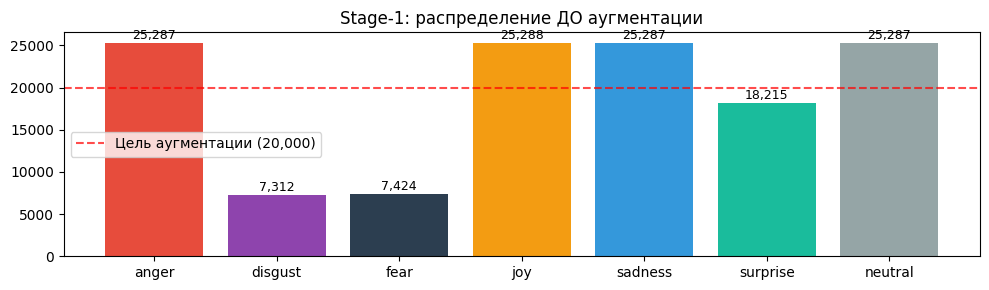

In [7]:
EMOTION_COLORS = {
    'anger':'#e74c3c','disgust':'#8e44ad','fear':'#2c3e50',
    'joy':'#f39c12','sadness':'#3498db','surprise':'#1abc9c','neutral':'#95a5a6',
}

df = stage1_ds['train'].to_pandas()
counts = df['label'].value_counts().sort_index()
total = len(df)

print('Распределение классов в Stage-1 train (ДО аугментации):')
for lid, cnt in counts.items():
    bar = '█' * int(cnt / total * 40)
    flag = '  ⚠ мало данных' if cnt < 3000 else ''
    print(f'  {EKMAN_ID2LABEL[lid]:<12}: {cnt:>7,}  ({cnt/total*100:4.1f}%)  {bar}{flag}')

fig, ax = plt.subplots(figsize=(10, 3))
labels_plot = [EKMAN_ID2LABEL[i] for i in counts.index]
bars = ax.bar(labels_plot, counts.values, color=[EMOTION_COLORS[l] for l in labels_plot])
ax.axhline(AUG_TARGET_S1, color='red', linestyle='--', alpha=0.7, label=f'Цель аугментации ({AUG_TARGET_S1:,})')
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{cnt:,}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Stage-1: распределение ДО аугментации')
ax.legend()
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/distribution_before_aug.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Аугментация Stage-1 (редкие классы)

Парафраз через `cointegrated/rut5-base-paraphraser` + обратный перевод `Helsinki-NLP RU→EN→RU`.
Аугментируются только классы ниже порога `AUG_TARGET_S1`.

> Ориентировочное время на T4: ~10–20 мин при `method='both'`.  
> Если нужно быстрее — установи `AUG_METHOD = 'backtranslation'` (~5 мин) или `USE_AUGMENTATION = False`.

Аугментация Stage-1 (метод=both, цель=20000/класс)...
  anger       : 25287  ≥ 20000 — skip
  disgust     :  7312  → need +12688  (2 variants/text)
  Loading cointegrated/rut5-base-paraphraser...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  Loading Helsinki-NLP/opus-mt-ru-en and opus-mt-en-ru...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

...

    → added 12688 augmented examples (generated 20563 valid)
  fear        :  7424  → need +12576  (2 variants/text)
    → added 12576 augmented examples (generated 20888 valid)
  joy         : 25288  ≥ 20000 — skip
  sadness     : 25287  ≥ 20000 — skip
  surprise    : 18215  → need +1785  (1 variants/text)
    → added 1785 augmented examples (generated 30546 valid)
  neutral     : 25287  ≥ 20000 — skip

Total added: 27049 examples
New training distribution:
  anger       : 25,287
  disgust     : 20,000
  fear        : 20,000
  joy         : 25,288
  sadness     : 25,287
  surprise    : 20,000
  neutral     : 25,287


Saving the dataset (0/1 shards):   0%|          | 0/161149 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/23665 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/27842 [00:00<?, ? examples/s]

Stage-1 augmented сохранён: /kaggle/working/stage1_data_augmented


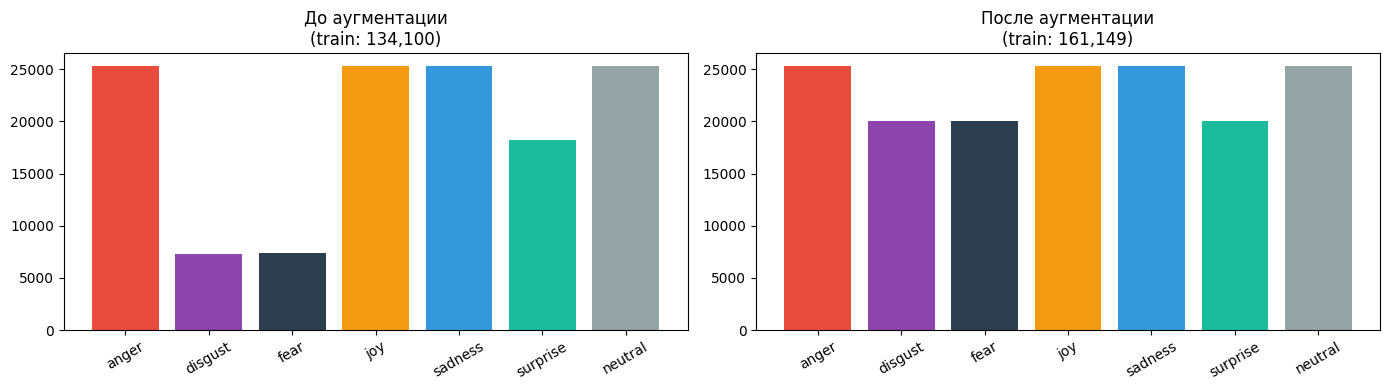


Сравнение Stage-1:
  Класс               До     После        Δ
  --------------------------------------------
  anger           25,287    25,287  +    0
  disgust          7,312    20,000  +12,688 ← добавлено
  fear             7,424    20,000  +12,576 ← добавлено
  joy             25,288    25,288  +    0
  sadness         25,287    25,287  +    0
  surprise        18,215    20,000  +1,785 ← добавлено
  neutral         25,287    25,287  +    0


In [15]:
from src.augmentation import augment_rare_classes

if not USE_AUGMENTATION:
    print('Аугментация отключена (USE_AUGMENTATION=False). Используем оригинальный Stage-1.')
    stage1_aug_ds = stage1_ds

elif os.path.exists(S1_AUG_DATA_PATH):
    print('Загружаем готовый аугментированный Stage-1 с диска...')
    stage1_aug_ds = load_from_disk(S1_AUG_DATA_PATH)

else:
    print(f'Аугментация Stage-1 (метод={AUG_METHOD}, цель={AUG_TARGET_S1}/класс)...')
    stage1_aug_ds = augment_rare_classes(
        dataset=stage1_ds,
        label_names=LABEL_NAMES,
        target_per_class=AUG_TARGET_S1,
        method=AUG_METHOD,
        n_variants=AUG_N_VARIANTS,
        batch_size=AUG_BATCH_SIZE,
        seed=SEED,
    )
    stage1_aug_ds.save_to_disk(S1_AUG_DATA_PATH)
    print(f'Stage-1 augmented сохранён: {S1_AUG_DATA_PATH}')

# Визуализация до/после
df_before = stage1_ds['train'].to_pandas()
df_after  = stage1_aug_ds['train'].to_pandas()
c_before  = df_before['label'].value_counts().sort_index()
c_after   = df_after['label'].value_counts().sort_index()

if USE_AUGMENTATION:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, (counts, title) in zip(axes, [(c_before, 'До аугментации'), (c_after, 'После аугментации')]):
        labels = [EKMAN_ID2LABEL[i] for i in counts.index]
        ax.bar(labels, counts.values, color=[EMOTION_COLORS[l] for l in labels])
        ax.set_title(f'{title}\n(train: {counts.sum():,})')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'{WORKING_DIR}/s1_augmentation.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nСравнение Stage-1:')
    print(f'  {"Класс":<12}  {"До":>8}  {"После":>8}  {"Δ":>7}')
    print('  ' + '-' * 44)
    for lid in range(NUM_LABELS):
        before = c_before.get(lid, 0)
        after  = c_after.get(lid, 0)
        delta  = after - before
        flag   = ' ← добавлено' if delta > 0 else ''
        print(f'  {LABEL_NAMES[lid]:<12}  {before:>8,}  {after:>8,}  +{delta:>5,}{flag}')
else:
    labels = [EKMAN_ID2LABEL[i] for i in c_before.index]
    plt.figure(figsize=(9, 3))
    plt.bar(labels, c_before.values, color=[EMOTION_COLORS[l] for l in labels])
    plt.title(f'Stage-1 train: {c_before.sum():,} примеров')
    plt.tight_layout(); plt.show()

## 5. Загрузка Stage-2 (чистый нативный корпус)

In [16]:
from src.data_loader import load_stage2_clean

if os.path.exists(S2_DATA_PATH):
    print('Загружаем готовый Stage-2 датасет с диска...')
    stage2_ds = load_from_disk(S2_DATA_PATH)
else:
    print('Собираем Stage-2 (чистый) датасет...')
    # cedr_m7 заменяет base cedr — те же тексты + disgust и neutral
    stage2_ds = load_stage2_clean(
        use_cedr=False, use_cedr_m7=True,
        use_brighter_hf=True, use_aniemore=True,
        seed=SEED,
    )
    stage2_ds = stage2_ds.map(
        lambda b: preprocess_batch(b, clean=True), batched=True, batch_size=500
    )
    stage2_ds.save_to_disk(S2_DATA_PATH)
    print(f'Stage-2 сохранён: {S2_DATA_PATH}')

print('\nStage-2 splits:')
for split in stage2_ds:
    print(f'  {split:12s}: {len(stage2_ds[split]):,}')

print('\nПокрытие классов в Stage-2 train:')
df2 = stage2_ds['train'].to_pandas()
total2 = len(df2)
for lid in range(NUM_LABELS):
    cnt = (df2['label'] == lid).sum()
    print(f'  {EKMAN_ID2LABEL[lid]:<12}: {cnt:>5,}  ({cnt/total2*100:.1f}%)')

Собираем Stage-2 (чистый) датасет...
Loading Aniemore/cedr-m7...
  columns: text='text', label='labels'  feat=List  sample=['neutral']
  → 11,292 examples (cedr-m7, 7 classes, native RU)
Loading brighter-dataset/BRIGHTER-emotion-categories (rus)...
  → 5,077 examples (BRIGHTER, native RU, 6 classes)
  Loading Aniemore/resd_annotated...
  → 1,675 examples (Aniemore/resd_annotated, native RU, 7 classes)

Merging datasets...
  cedr_m7: 11,292 examples
  brighter_hf: 5,077 examples
  aniemore: 1,675 examples

Total before split: 18,044
Label distribution:
  anger       :  1,801  (10.0%)
  disgust     :    814  (4.5%)
  fear        :  1,725  (9.6%)
  joy         :  4,644  (25.7%)
  sadness     :  2,894  (16.0%)
  surprise    :    415  (2.3%)
  neutral     :  5,751  (31.9%)

Final splits:
  train       : 13,036
  validation  : 2,301
  test        : 2,707


Map:   0%|          | 0/13036 [00:00<?, ? examples/s]

Map:   0%|          | 0/2301 [00:00<?, ? examples/s]

Map:   0%|          | 0/2707 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/13036 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2301 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2707 [00:00<?, ? examples/s]

Stage-2 сохранён: /kaggle/working/stage2_data

Stage-2 splits:
  train       : 13,036
  validation  : 2,301
  test        : 2,707

Покрытие классов в Stage-2 train:
  anger       : 1,301  (10.0%)
  disgust     :   588  (4.5%)
  fear        : 1,246  (9.6%)
  joy         : 3,355  (25.7%)
  sadness     : 2,091  (16.0%)
  surprise    :   300  (2.3%)
  neutral     : 4,155  (31.9%)


## 6. Аугментация Stage-2

In [20]:
if not USE_AUGMENTATION:
    print('Аугментация отключена. Используем оригинальный Stage-2.')
    stage2_aug_ds = stage2_ds

elif os.path.exists(S2_AUG_DATA_PATH):
    print('Загружаем готовый аугментированный Stage-2 с диска...')
    stage2_aug_ds = load_from_disk(S2_AUG_DATA_PATH)

else:
    print(f'Аугментация Stage-2 (метод={AUG_METHOD}, цель={AUG_TARGET_S2}/класс)...')
    stage2_aug_ds = augment_rare_classes(
        dataset=stage2_ds,
        label_names=LABEL_NAMES,
        target_per_class=AUG_TARGET_S2,
        method=AUG_METHOD,
        n_variants=AUG_N_VARIANTS_S2,
        batch_size=AUG_BATCH_SIZE,
        seed=SEED,
    )
    stage2_aug_ds.save_to_disk(S2_AUG_DATA_PATH)
    print(f'Stage-2 augmented сохранён: {S2_AUG_DATA_PATH}')

print('\nStage-2 (финальный для обучения):')
df2a = stage2_aug_ds['train'].to_pandas()
total2a = len(df2a)
for lid in range(NUM_LABELS):
    cnt = (df2a['label'] == lid).sum()
    flag = '' if cnt >= AUG_TARGET_S2 else '  ← мало данных!'
    print(f'  {EKMAN_ID2LABEL[lid]:<12}: {cnt:>5,}  ({cnt/total2a*100:.1f}%){flag}')

Аугментация Stage-2 (метод=both, цель=1200/класс)...
  anger       :  1301  ≥ 1200 — skip
  disgust     :   588  → need +612  (2 variants/text)
  Loading cointegrated/rut5-base-paraphraser...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  Loading Helsinki-NLP/opus-mt-ru-en and opus-mt-en-ru...


/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


...

    → added 612 augmented examples (generated 1653 valid)
  fear        :  1246  ≥ 1200 — skip
  joy         :  3355  ≥ 1200 — skip
  sadness     :  2091  ≥ 1200 — skip
  surprise    :   300  → need +900  (3 variants/text)
    → added 900 augmented examples (generated 1095 valid)
  neutral     :  4155  ≥ 1200 — skip

Total added: 1512 examples
New training distribution:
  anger       :  1,301
  disgust     :  1,200
  fear        :  1,246
  joy         :  3,355
  sadness     :  2,091
  surprise    :  1,200
  neutral     :  4,155


Saving the dataset (0/1 shards):   0%|          | 0/14548 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2301 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2707 [00:00<?, ? examples/s]

Stage-2 augmented сохранён: /kaggle/working/stage2_data_augmented

Stage-2 (финальный для обучения):
  anger       : 1,301  (8.9%)
  disgust     : 1,200  (8.2%)
  fear        : 1,246  (8.6%)
  joy         : 3,355  (23.1%)
  sadness     : 2,091  (14.4%)
  surprise    : 1,200  (8.2%)
  neutral     : 4,155  (28.6%)


## Итог

Данные подготовлены и сохранены на диск.

| Датасет | Путь | Описание |
|---|---|---|
| Stage-1 raw | `stage1_data/` | До аугментации |
| Stage-1 aug | `stage1_data_augmented/` | После аугментации |
| Stage-2 raw | `stage2_data/` | Чистый нативный RU |
| Stage-2 aug | `stage2_data_augmented/` | После аугментации |

**Следующий шаг:** запустить `02_training.ipynb`